# LNR stock Price Forecasting — Introducing the Agentic Predictor (Notebook 2 of 7)

This notebook introduces the **progressive capability staircase** for agentic
forecasting by studying a single, high-stakes prediction origin:
**March 2, 2026** — the day news of Persian Gulf shipping-lane disruptions
began reaching energy markets.

> **Prerequisite:** Run [`01_lnr_case_study.ipynb`](01_lnr_case_study.ipynb) first — it establishes why a price-only baseline fails during regime breaks.

We build four predictors of increasing sophistication, each implementing
the standard `Predictor` interface so that the outputs are directly
comparable and can slot into the systematic backtest in Notebook 4.

| Step | Predictor | Capability |
|------|-----------|------------|
| 1 | `ProphetPredictor` | Statistical baseline — extrapolates trend and seasonality |
| 2 | `SampledTrajectoryLLMPredictor` | Direct-prompting LLMP — no tools, reasons from history text |
| 3 | `AgentPredictor` (news) | News-grounded agent — bounded Google Search, strict temporal cutoff |
| 4 | `AgentPredictor` (code+news) | Code-executing agent — E2B sandbox code execution + 2 forecasting skills |

---
## 1. Setup & Data Registration

In [49]:
import sys
import warnings
from pathlib import Path


ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / "implementations").is_dir()),
    Path.cwd().resolve(),
)
sys.path[:0] = [str(ROOT / "aieng-forecasting"), str(ROOT / "implementations")]

warnings.filterwarnings("ignore")

import pandas as pd
from energy_oil_for_lnr.data import LNR_SERIES_ID, build_lnr_service


# ── Data service ──────────────────────────────────────────────────────────
data_service = build_lnr_service()

# ── Single forecast origin for this notebook ──────────────────────────────
AS_OF = pd.Timestamp("2026-03-01")  # context available the day before origin
ORIGIN = pd.Timestamp("2026-03-02")  # the day we are predicting *from*

ctx = data_service.context(as_of=AS_OF)
full_df = ctx.get_series(LNR_SERIES_ID)

print(f"Trading days in cache up to {AS_OF.date()}: {len(full_df)}")
print(f"Last LNR adjusted close: CAD ${full_df['value'].iloc[-1]:.2f}/share on {str(full_df['timestamp'].iloc[-1])[:10]}")

Trading days in cache up to 2026-03-01: 2800
Last LNR adjusted close: CAD $93.15/share on 2026-02-27


In [50]:
from aieng.forecasting.evaluation.task import ForecastingTask


# The forecasting task mirrors the spec in specs/energy_oil_backtest.yaml
task = ForecastingTask(
    task_id="lnr_oil_price_forecast",
    target_series_id=LNR_SERIES_ID,
    horizons=[5, 10, 21],
    frequency="B",
    description="LNR stock adjusted-close equity — 5, 10, 21 business days ahead.",
)

print("Task:", task.task_id)
print("Horizons:", task.horizons)
print("Origin context as_of:", ctx.as_of)

Task: lnr_oil_price_forecast
Horizons: [5, 10, 21]
Origin context as_of: 2026-03-01 00:00:00


---
## 2. Step 1 — Prophet Baseline

Prophet fits a decomposable time-series model (trend + seasonality) on the
daily close history. It is deliberately blind to geopolitics — whatever
is happening in the Persian Gulf, Prophet does not know.

We wrap Prophet in a `Predictor` subclass so it produces standard
`Prediction` objects with the full 11-quantile grid.
The same wrapper will be used in Notebook 4's stateless backtest loop.

In [51]:
from energy_oil_for_lnr.prophet_baseline import ProphetPredictor


prophet = ProphetPredictor()

In [52]:
prophet_preds = prophet.predict(task, ctx)

print(f"Prophet forecast from {AS_OF.date()} (as_of) → {ORIGIN.date()} (origin):\n")
for p in prophet_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[prophet_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )

19:14:29 - cmdstanpy - INFO - Chain [1] start processing


19:14:30 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast from 2026-03-01 (as_of) → 2026-03-02 (origin):

  h= 5d  point=$72.00  80%CI=[$66.85, $77.15]
  h=10d  point=$72.07  80%CI=[$66.90, $77.24]
  h=21d  point=$72.24  80%CI=[$67.20, $77.27]


---
## 3. Step 2 — Direct-Prompting LLM Process (LLMP)

`SampledTrajectoryLLMPredictor` sends the price history as a structured JSON payload
directly to Gemini and asks it to return a calibrated probabilistic forecast.
There is no search tool and no code execution — the model must reason entirely
from numerical history.

**Data leakage caveat:** Gemini was trained on data that includes LNR prices
through at least late 2024. For origins in 2026, the model may have implicit
knowledge of historical events — this is a known limitation of LLMPs that we
cannot fully control. The LLMP is included as a calibration reference, not as
a clean counterfactual.

In [53]:
from aieng.forecasting.methods import SampledTrajectoryLLMPredictor, SampledTrajectoryLLMPredictorConfig


# Models: "gemini-3.1-flash-lite-preview" (lite/default) · "gemini-3.5-flash" (advanced)
llmp_config = SampledTrajectoryLLMPredictorConfig(
    model="gemini-3.1-flash-lite-preview",
    # model="gemini-3.5-flash",  # advanced
    n_samples=3,
)

print("SampledTrajectoryLLMPredictorConfig:")
print(f"  model:    {llmp_config.model}")
print(f"  n_samples: {llmp_config.n_samples}")

SampledTrajectoryLLMPredictorConfig:
  model:    gemini-3.1-flash-lite-preview
  n_samples: 3


In [54]:
llmp = SampledTrajectoryLLMPredictor(llmp_config)
llmp_preds = llmp.predict(task, ctx)

print("LLMP forecast (no tools):\n")
for p in llmp_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[llmp_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )

LLMP forecast (no tools):

  h= 5d  point=$93.42  80%CI=[$92.62, $93.84]
  h=10d  point=$94.55  80%CI=[$91.99, $95.18]
  h=21d  point=$96.35  80%CI=[$90.80, $98.37]


---
## 4. Step 3 — News-Grounded Agent

We import `build_lnr_news_config` from the `analyst_agent` module and wrap it
in an `AgentPredictor`. The config wires a `ContextRetrievalConfig` sub-agent
that uses Google Search with a strict `cutoff_date` enforcement.

The key design constraints — visible in the config below — are:
- The root agent's instruction contains three sections: `## Role`,
  `## Forecasting contract`, and `## Analysis discipline`.
- The context sub-agent's instruction reads `cutoff_date` and `query` from
  the incoming JSON payload (produced by `ContextRetrievalRequest`).
- The prompt builder sends a structured JSON payload, not a free-form string,
  including `standard_quantiles` explicitly.

In [55]:
from energy_oil_for_lnr.analyst_agent import (
    LnrPriceForecastPromptBuilder,
    build_lnr_agent_predictor,
    build_lnr_news_config,
)


# Models: "gemini-3.1-flash-lite-preview" (lite/default) · "gemini-3.5-flash" (advanced)
news_config = build_lnr_news_config(
    model="gemini-3.1-flash-lite-preview"
    # model="gemini-3.5-flash"  # advanced
)

print("=== Root agent instruction (first 1000 chars) ===")
print(news_config.instruction[:1000])
print("\n=== Context retrieval instruction (first 500 chars) ===")
print(news_config.context_retrieval.instruction[:500])
print("\nContext retrieval enabled:", news_config.context_retrieval.enabled)
print("Context retrieval model:", news_config.context_retrieval.search_model)

=== Root agent instruction (first 1000 chars) ===
## Role

You are an expert LNR LNR stock market analyst. You produce calibrated probabilistic price forecasts for LNR LNR stock futures, grounded in supply/demand fundamentals, geopolitical risk, and historical price dynamics.

## Forecasting contract

You will receive a JSON payload containing:
- `task`: the task identifier
- `as_of`: the forecast origin date in YYYY-MM-DD format
- `horizons`: a list of integer horizon steps (business days ahead)
- `standard_quantiles`: the exact quantile levels you must produce
- `target_summary`: last close price, 52-week range, and observation count
- `target_history_csv`: LNR daily close history (recent 6 months daily, older history as weekly averages)

Rules:
1. Produce one forecast for each horizon listed in `horizons`.
2. Use exactly the quantile levels from `standard_quantiles` — no additions, no omissions.
3. `point_forecast` must exactly equal the 0.50 quantile value.
4. Quantile values must 

In [56]:
# Inspect the prompt payload that will be sent to the agent
prompt_builder = LnrPriceForecastPromptBuilder()
sample_prompt = prompt_builder(task=task, context=ctx)

print("=== Prompt payload sent to agent (first 800 chars) ===")
print(sample_prompt[:800])
print("\n...[history_csv truncated]...")

=== Prompt payload sent to agent (first 800 chars) ===
{
  "task": "lnr_oil_price_forecast",
  "as_of": "2026-03-01",
  "horizons": [
    5,
    10,
    21
  ],
  "standard_quantiles": [
    0.05,
    0.1,
    0.2,
    0.3,
    0.4,
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    0.95
  ],
  "target_summary": {
    "last_close_usd_bbl": 93.1454086303711,
    "last_date": "2026-02-27",
    "n_trading_days": 2800,
    "52w_high": 94.06684875488281,
    "52w_low": 43.25108337402344
  },
  "target_history_csv": "date,close\n2015-01-04,61.90\n2015-01-11,60.70\n2015-01-18,59.69\n2015-01-25,59.49\n2015-02-01,61.68\n2015-02-08,66.83\n2015-02-15,68.53\n2015-02-22,69.39\n2015-03-01,69.06\n2015-03-08,67.69\n2015-03-15,66.99\n2015-03-22,67.03\n2015-03-29,67.38\n2015-04-05,68.59\n2015-04-12,68.89\n2015-04-19,68.84\n2015-04-26,66.52\n2015-05-03,64.30\n2015

...[history_csv truncated]...


In [57]:
news_predictor = build_lnr_agent_predictor(news_config)

print(f"Predictor ID: {news_predictor.predictor_id}")
print("Running news-grounded agent... (this calls Google Search)")

news_preds = news_predictor.predict(task, ctx)

print("\nNews-grounded agent forecast:\n")
for p in news_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[news_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )
if news_preds and news_preds[0].metadata.get("rationale"):
    print("\nAgent rationale:", news_preds[0].metadata["rationale"][:400])

Predictor ID: agent_predictor_lnr_analyst_news_gemini-3.1-flash-lite-preview_continuous
Running news-grounded agent... (this calls Google Search)

News-grounded agent forecast:

  h= 5d  point=$105.00  80%CI=[$99.50, $113.00]
  h=10d  point=$115.00  80%CI=[$105.00, $130.00]
  h=21d  point=$122.00  80%CI=[$110.00, $145.00]

Agent rationale: The forecast is driven by the severe geopolitical event of February 28, 2026, which resulted in the closure of the Strait of Hormuz. The analysis assumes a sustained supply disruption, market anticipation of SPR releases, and increased logistical costs due to mandatory tanker rerouting. Upward momentum is high in the short term, with uncertainty skewed heavily to the upside depending on the durati


---
## 5. Step 4 — Code-Executing Agent (E2B)

`build_lnr_code_exec_config()` adds two capabilities on top of the news config:

1. **E2B sandbox code execution** — the agent can write and run Python
   (pandas, numpy, scikit-learn, matplotlib) in a secure E2B container, see
   the output, and iterate before producing its final structured forecast.
   All LLM calls route through the Vector proxy (same as every other predictor).

2. **Two forecasting skills** — ADK `SkillToolset` provides reference data
   and code patterns on demand:
   - `statistical-analysis` — diagnostic patterns for the payload data (vol
     regime, anomaly detection, adaptive trend-window selection)
   - `trend-projection` — linear trend fit, CI calibration, and plausibility
     guard using the window determined by statistical-analysis

The skills follow the design rule from `docs/adk-skills-guide.md`: each
skill directory contains at least one real file in `references/` and the
instruction explicitly tells the agent **not** to call `run_skill_script`.

### Design constraints and skill philosophy

**Context is your data store.** All data the agent can use in code must
arrive via the JSON payload in the user message. The payload fields are:

| Field | Contents |
|---|---|
| `target_history_csv` | Mixed-frequency CSV string — recent 6 months daily, older history as weekly averages |
| `target_summary` | `last_close_cad_per_share`, `last_date`, `52w_high`, `52w_low`, `n_trading_days` |
| `as_of` | Forecast origin date |
| `horizons` | Integer list of horizon steps (business days) |
| `standard_quantiles` | Exact quantile grid the agent must produce |

There are no disk files, no database connections. The agent parses
`target_history_csv` using `io.StringIO` (not a file path) and emits
intermediate results via `print()` so they appear in the conversation.

**Skill philosophy.** The skills don't teach the agent how to use sklearn —
it already knows that. They signal *which analyses are worth running given the
payload you have*, and show the best way to get data in and structured results
out of the code execution environment. The patterns are illustrated with LNR
but the approach transfers: classify your vol regime, detect anomalies, adapt
your trend window accordingly.

**TODO (futures curve).** The natural next payload extension for LNR is a
futures curve snapshot — spot vs M1, M3, M6 spread (a few numbers, low token
cost) — which would unlock contango/backwardation regime detection in code.
See `LnrPriceForecastPromptBuilder` in `analyst_agent/agent.py` for where this
field would be added, and `statistical-analysis/references/analysis-patterns.md`
for where the corresponding pattern would live.

In [58]:
from energy_oil_for_lnr.analyst_agent import build_lnr_code_exec_config


# Models: "gemini-3.1-flash-lite-preview" (lite/default) · "gemini-3.5-flash" (advanced)
code_config = build_lnr_code_exec_config(
    model="gemini-3.1-flash-lite-preview"
    # model="gemini-3.5-flash"  # advanced
)

print("=== Code-exec agent config summary ===")
print(f"Code execution enabled:  {code_config.code_execution.enabled}")
print(f"Sandbox timeout (s):     {code_config.code_execution.sandbox_timeout_seconds}")
print(f"Skills directories ({len(code_config.skills_dirs)}):")
for sd in code_config.skills_dirs:
    print(f"  {sd.name}")
print("\n=== Skills supplement in instruction (last 600 chars of instruction) ===")
print(code_config.instruction[-600:])

=== Code-exec agent config summary ===
Code execution enabled:  True
Sandbox timeout (s):     3600
Skills directories (2):
  statistical-analysis
  trend-projection

=== Skills supplement in instruction (last 600 chars of instruction) ===
 input to the projection
   skill below.

2. `trend-projection` — run second. Provides code patterns for fitting a
   linear trend on the window chosen above, projecting point forecasts to
   each horizon, and calibrating 80% prediction interval widths.

**To use a skill:**
1. Call `list_skills` to see available skill names and descriptions.
2. Call `load_skill(<name>)` to read the skill's full instructions.
3. Call `load_skill_resource(<skill_name>, <file_path>)` to load a
   reference file (e.g. `references/lnr_benchmarks.json`).

These skills have NO scripts. Do not call `run_skill_script`.


In [59]:
code_predictor = build_lnr_agent_predictor(code_config)

print(f"Predictor ID: {code_predictor.predictor_id}")
print("Running code-executing agent... (calls Google Search + executes Python code)")

code_preds = code_predictor.predict(task, ctx)

print("\nCode-executing agent forecast:\n")
for p in code_preds:
    fc = p.payload
    print(
        f"  h={task.horizons[code_preds.index(p)]:>2}d  "
        f"point=${fc.point_forecast:.2f}  "
        f"80%CI=[${fc.quantiles[0.10]:.2f}, ${fc.quantiles[0.90]:.2f}]"
    )
if code_preds and code_preds[0].metadata.get("rationale"):
    print("\nAgent rationale:", code_preds[0].metadata["rationale"][:400])

Predictor ID: agent_predictor_lnr_analyst_code_gemini-3.1-flash-lite-preview_continuous
Running code-executing agent... (calls Google Search + executes Python code)
  Cell In[1], line 45
    """
    ^
_IncompleteInputError: incomplete input


Code-executing agent forecast:

  h= 5d  point=$94.64  80%CI=[$92.58, $96.70]
  h=10d  point=$96.02  80%CI=[$93.10, $98.93]
  h=21d  point=$99.05  80%CI=[$94.83, $103.28]

Agent rationale: The forecast is driven by a strong upward price trend observed in the final 30 trading days, compounded by significant geopolitical risk in the Middle East following the February 28, 2026 conflict escalation. This volatility and uncertainty regarding the Strait of Hormuz underpin the upward trend projection and the wider prediction intervals.


---
## 6. Side-by-Side Comparison

All four predictors return standard `Prediction` objects, so we can
compare them in a uniform table. We also show the actual LNR prices
at each horizon to contextualise the forecasts.

In [62]:
import matplotlib.pyplot as plt
import numpy as np


# Collect actual adjusted closes for horizon dates.
future_ctx = data_service.context(as_of=ORIGIN + pd.offsets.BDay(25))
future_df = future_ctx.get_series(LNR_SERIES_ID)


def get_actual(h: int) -> float | None:
    target = ORIGIN + pd.offsets.BDay(h)
    future_df["ts"] = pd.to_datetime(future_df["timestamp"])
    row = future_df[future_df["ts"] >= target]
    if row.empty:
        return None
    return float(row.iloc[0]["value"])


rows = []
predictor_sets = [
    ("Prophet", prophet_preds),
    ("LLMP", llmp_preds),
    ("Agent (News)", news_preds),
    ("Agent (Code+News)", code_preds),
]

for h_idx, h in enumerate(task.horizons):
    actual = get_actual(h)
    actual_date = ORIGIN + pd.offsets.BDay(h)
    for name, preds in predictor_sets:
        if preds and h_idx < len(preds):
            fc = preds[h_idx].payload
            rows.append(
                {
                    "Horizon": f"h={h}d",
                    "Predictor": name,
                    "Point (CAD/share)": f"{fc.point_forecast:.2f}",
                    "p10 (CAD/share)": f"{fc.quantiles[0.10]:.2f}",
                    "p90 (CAD/share)": f"{fc.quantiles[0.90]:.2f}",
                    "Actual date": actual_date.date(),
                    "Actual adjusted close (CAD/share)": f"{actual:.2f}" if actual is not None else "N/A",
                }
            )

import pandas as pd

comparison = pd.DataFrame(rows).set_index(["Horizon", "Predictor"])
print(comparison.to_string())

                          Point (CAD/share) p10 (CAD/share) p90 (CAD/share) Actual date Actual adjusted close (CAD/share)
Horizon Predictor                                                                                                        
h=5d    Prophet                       72.00           66.85           77.15  2026-03-09                             86.41
        LLMP                          93.42           92.62           93.84  2026-03-09                             86.41
        Agent (News)                 105.00           99.50          113.00  2026-03-09                             86.41
        Agent (Code+News)             94.64           92.58           96.70  2026-03-09                             86.41
h=10d   Prophet                       72.07           66.90           77.24  2026-03-16                             86.10
        LLMP                          94.55           91.99           95.18  2026-03-16                             86.10
        Agent (News)    

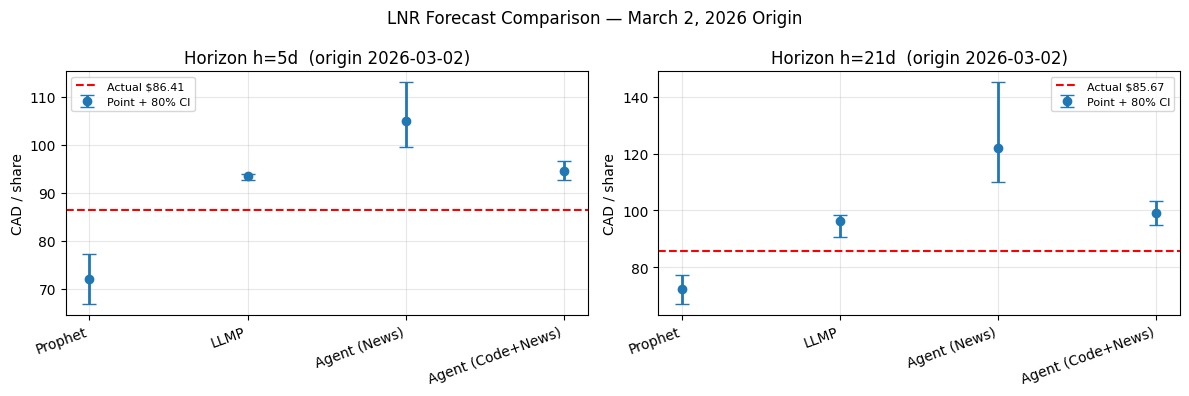

In [63]:
# Point forecast comparison chart (h=5 and h=21)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, h_idx, h in [(axes[0], 0, 5), (axes[1], 2, 21)]:
    names, points, lo, hi, actuals = [], [], [], [], []
    actual_val = get_actual(h)

    for name, preds in predictor_sets:
        if preds and h_idx < len(preds):
            fc = preds[h_idx].payload
            names.append(name)
            points.append(fc.point_forecast)
            lo.append(fc.quantiles[0.10])
            hi.append(fc.quantiles[0.90])

    x = range(len(names))
    ax.errorbar(
        x,
        points,
        yerr=[np.array(points) - np.array(lo), np.array(hi) - np.array(points)],
        fmt="o",
        capsize=5,
        linewidth=2,
        label="Point + 80% CI",
    )
    if actual_val:
        ax.axhline(actual_val, color="red", linestyle="--", label=f"Actual ${actual_val:.2f}")
    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=20, ha="right")
    ax.set_title(f"Horizon h={h}d  (origin {ORIGIN.date()})")
    ax.set_ylabel("CAD / share")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("LNR Forecast Comparison — March 2, 2026 Origin", fontsize=12)
plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **All four predictors share the same `Predictor` interface.** The same
   `predict(task, context)` call works whether the model is a statistical
   trend-fitter or a tool-using agent. This is what makes systematic
   backtesting in Notebook 4 possible.

2. **`AgentConfig` factories encapsulate capability.** By importing
   `build_lnr_news_config()` and `build_lnr_code_exec_config()` from
   `analyst_agent/`, the notebook stays clean — configs are reproducible and
   importable from any script or notebook.

3. **Skills guide code execution, not sklearn usage.** The two ADK skills
   (`statistical-analysis`, `trend-projection`) provide payload-aware code
   patterns and reference benchmarks the agent loads on demand. They teach
   effective use of code exec within the Gemini context-as-data-store
   constraints — not Python basics. Following the design rule in
   `docs/adk-skills-guide.md`, no scripts are present and the instruction
   explicitly forbids `run_skill_script`.

4. **Temporal cutoffs prevent data leakage.** The `ContextRetrievalConfig`
   sub-agent enforces a `cutoff_date` on every search call, allowing the same
   agent to be used safely in historical backtests.

→ **Notebooks 4–6** build on these four predictors: Notebook 4 runs a systematic
2025 backtest across all stateless methods; Notebooks 5–6 introduce the adaptive
agent and compare it against the stateless top-performers on held-out 2025+ data.